In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")  # statsmodels is chatty about convergence

# Plot setup
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)

# Paths
PROCESSED_DIR = Path("..") / "data" / "processed"
FIG_DIR = Path("..") / "results" / "figures"
RESULTS_DIR = Path("..") / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


In [2]:
# Load cleaned data and modeling SKU subset
sales = pd.read_parquet(PROCESSED_DIR / "sales_clean.parquet")
modeling_skus = pd.read_parquet(PROCESSED_DIR / "modeling_skus.parquet")

# Filter to modeling SKUs only
sales = sales[sales["id"].isin(modeling_skus["id"])].copy()
sales["date"] = pd.to_datetime(sales["date"])

print(f"Sales rows: {len(sales):,}")
print(f"SKUs: {sales['id'].nunique()}")
print(f"Date range: {sales['date'].min().date()} to {sales['date'].max().date()}")

Sales rows: 1,743,302
SKUs: 1082
Date range: 2011-01-29 to 2016-05-22


In [3]:
# Define the train/validation/test split — time-based, not random
# Last 28 days = test (we'll evaluate models here)
# Previous 28 days = validation (we'll tune any hyperparameters here)
# Everything before = train

max_date = sales["date"].max()
test_start = max_date - pd.Timedelta(days=27)      # 28-day test window
val_start = test_start - pd.Timedelta(days=28)     # 28-day val window

print(f"Train end:   {val_start - pd.Timedelta(days=1)}")
print(f"Val:         {val_start.date()} → {test_start - pd.Timedelta(days=1)}")
print(f"Test:        {test_start.date()} → {max_date.date()}")

# Add a partition column for convenience
sales["partition"] = "train"
sales.loc[(sales["date"] >= val_start) & (sales["date"] < test_start), "partition"] = "val"
sales.loc[sales["date"] >= test_start, "partition"] = "test"

print(f"\nRow counts per partition:")
print(sales["partition"].value_counts())

Train end:   2016-03-27 00:00:00
Val:         2016-03-28 → 2016-04-24 00:00:00
Test:        2016-04-25 → 2016-05-22

Row counts per partition:
partition
train    1682710
val        30296
test       30296
Name: count, dtype: int64


In [5]:
# Import our metrics module
import sys
sys.path.insert(0, "..")
from src.metrics import wmape, bias, rmse, evaluate_forecasts

# Quick sanity check
test_actual = np.array([10, 5, 0, 8])
test_forecast = np.array([9, 6, 1, 7])
print(f"WMAPE: {wmape(test_actual, test_forecast):.1f}%")
print(f"Bias:  {bias(test_actual, test_forecast):+.2f}")
print(f"RMSE:  {rmse(test_actual, test_forecast):.2f}")

WMAPE: 17.4%
Bias:  +0.00
RMSE:  1.00


In [6]:
# The "skeleton" — one row per SKU per test-period date
test_data = sales[sales["partition"] == "test"][["id", "date", "units_sold"]].copy()
test_data = test_data.rename(columns={"units_sold": "actual"})

print(f"Test rows: {len(test_data):,}")
print(f"SKUs × days: {test_data['id'].nunique()} × {test_data['date'].nunique()}")
print(test_data.head())

Test rows: 30,296
SKUs × days: 1082 × 28
                               id       date  actual
1913  FOODS_1_001_CA_1_evaluation 2016-04-25       2
1914  FOODS_1_001_CA_1_evaluation 2016-04-26       0
1915  FOODS_1_001_CA_1_evaluation 2016-04-27       0
1916  FOODS_1_001_CA_1_evaluation 2016-04-28       0
1917  FOODS_1_001_CA_1_evaluation 2016-04-29       0


In [7]:
# Seasonal naive: forecast = same day-of-week, one week ago
# For day t, forecast = actual at day t-7
# This is the gold-standard baseline for daily retail data

def seasonal_naive_forecast(sales: pd.DataFrame, test_dates: pd.DatetimeIndex,
                            season_length: int = 7) -> pd.DataFrame:
    """For each SKU, forecast each test day as the actual from `season_length` days prior."""
    forecasts = []
    sales_indexed = sales.set_index(["id", "date"])["units_sold"]

    for sku in tqdm(sales["id"].unique(), desc="Seasonal Naive"):
        for test_date in test_dates:
            lookback = test_date - pd.Timedelta(days=season_length)
            try:
                pred = sales_indexed.loc[(sku, lookback)]
            except KeyError:
                pred = 0  # SKU has no data 7 days before — shouldn't happen with our filter
            forecasts.append({"id": sku, "date": test_date, "forecast": pred})

    return pd.DataFrame(forecasts)

test_dates = sorted(test_data["date"].unique())
test_dates = pd.to_datetime(test_dates)

naive_fc = seasonal_naive_forecast(sales, test_dates)
naive_fc = naive_fc.rename(columns={"forecast": "naive"})

# Merge into our predictions dataframe
test_data = test_data.merge(naive_fc, on=["id", "date"], how="left")
print(f"\nNaive forecasts added. Sample:")
print(test_data.head())

Seasonal Naive: 100%|██████████| 1082/1082 [00:05<00:00, 213.56it/s]



Naive forecasts added. Sample:
                            id       date  actual  naive
0  FOODS_1_001_CA_1_evaluation 2016-04-25       2      4
1  FOODS_1_001_CA_1_evaluation 2016-04-26       0      1
2  FOODS_1_001_CA_1_evaluation 2016-04-27       0      1
3  FOODS_1_001_CA_1_evaluation 2016-04-28       0      0
4  FOODS_1_001_CA_1_evaluation 2016-04-29       0      1


In [8]:
# Evaluate naive baseline overall
naive_overall = evaluate_forecasts(
    test_data.rename(columns={"naive": "forecast"}),
    actual_col="actual",
    forecast_col="forecast"
)
print("Naive baseline — overall:")
print(naive_overall.round(2))

# And by demand pattern (join in pattern info)
test_data_w_pattern = test_data.merge(
    modeling_skus[["id", "pattern"]], on="id", how="left"
)

naive_by_pattern = evaluate_forecasts(
    test_data_w_pattern.rename(columns={"naive": "forecast"}),
    actual_col="actual",
    forecast_col="forecast",
    group_cols=["pattern"]
)
print("\nNaive baseline — by demand pattern:")
print(naive_by_pattern.round(2))

Naive baseline — overall:
   wmape  bias  rmse  n_obs
0  73.29 -0.05  3.55  30296

Naive baseline — by demand pattern:
        pattern   wmape  bias  rmse  n_obs
0       erratic   91.68 -0.05  2.99  20496
1  intermittent   69.07 -1.07  6.09    140
2         lumpy  131.14 -0.03  1.65   2800
3        smooth   54.05 -0.06  5.20   6860


In [9]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

def fit_ets_for_sku(history: pd.Series, n_forecast: int) -> np.ndarray:
    """
    Fit an ETS model on the history and forecast the next n days.
    Uses additive trend and additive weekly seasonality where possible.
    Falls back to simpler models if data is too sparse.
    """
    history = history.fillna(0).astype(float)

    # ETS with weekly seasonality needs at least 2 full seasons (14 days)
    if len(history) < 28 or history.sum() == 0:
        return np.full(n_forecast, history.mean() if history.sum() > 0 else 0)

    try:
        model = ExponentialSmoothing(
            history,
            trend=None,           # Most retail SKUs don't have strong trends — keep it simple
            seasonal="add",
            seasonal_periods=7,
            initialization_method="estimated"
        )
        fit = model.fit(optimized=True)
        fc = fit.forecast(n_forecast)
        return np.maximum(fc.values, 0)  # forecasts can't go negative for demand
    except Exception:
        # Fall back to mean if fitting fails
        return np.full(n_forecast, history.mean())


def run_ets_all_skus(sales: pd.DataFrame, test_dates: pd.DatetimeIndex) -> pd.DataFrame:
    """Loop through SKUs, generate forecasts, return long dataframe."""
    forecasts = []
    train_end = test_dates.min() - pd.Timedelta(days=1)

    for sku in tqdm(sales["id"].unique(), desc="ETS"):
        sku_history = sales[(sales["id"] == sku) & (sales["date"] <= train_end)]
        sku_history = sku_history.sort_values("date")["units_sold"]
        fc = fit_ets_for_sku(sku_history, len(test_dates))
        for d, f in zip(test_dates, fc):
            forecasts.append({"id": sku, "date": d, "forecast": f})

    return pd.DataFrame(forecasts)

ets_fc = run_ets_all_skus(sales, test_dates)
ets_fc = ets_fc.rename(columns={"forecast": "ets"})
test_data = test_data.merge(ets_fc, on=["id", "date"], how="left")
print("ETS forecasts added.")

ETS:   0%|          | 1/1082 [00:00<03:29,  5.16it/s]c:\Users\rajch\PortFolio\forecast-to-inventory\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\rajch\PortFolio\forecast-to-inventory\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
ETS:   0%|          | 2/1082 [00:00<02:54,  6.18it/s]c:\Users\rajch\PortFolio\forecast-to-inventory\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users

ETS forecasts added.


In [10]:
# Evaluate ETS
print("ETS — overall:")
print(evaluate_forecasts(
    test_data.rename(columns={"ets": "forecast"}),
    actual_col="actual", forecast_col="forecast"
).round(2))

test_data_w_pattern = test_data.merge(modeling_skus[["id", "pattern"]], on="id", how="left")
print("\nETS — by demand pattern:")
print(evaluate_forecasts(
    test_data_w_pattern.rename(columns={"ets": "forecast"}),
    actual_col="actual", forecast_col="forecast",
    group_cols=["pattern"]
).round(2))

ETS — overall:
   wmape  bias  rmse  n_obs
0  61.37 -0.22  3.11  30296

ETS — by demand pattern:
        pattern   wmape  bias  rmse  n_obs
0       erratic   76.91 -0.22  2.70  20496
1  intermittent  103.25 -2.93  8.67    140
2         lumpy  109.98 -0.14  1.27   2800
3        smooth   44.62 -0.19  4.32   6860


In [11]:
import lightgbm as lgb

def build_features(sales: pd.DataFrame) -> pd.DataFrame:
    """
    Build features for LightGBM:
    - lag features (sales N days ago)
    - rolling means (avg over past N days)
    - calendar features
    - SNAP flag
    """
    df = sales.sort_values(["id", "date"]).copy()

    # Lag features
    for lag in [7, 14, 28]:
        df[f"lag_{lag}"] = df.groupby("id")["units_sold"].shift(lag)

    # Rolling means (shifted by 1 to avoid leakage)
    for window in [7, 14, 28]:
        df[f"rolling_mean_{window}"] = (
            df.groupby("id")["units_sold"]
            .shift(1)
            .rolling(window)
            .mean()
            .reset_index(level=0, drop=True)
        )

    # Calendar features
    df["day_of_week"] = df["date"].dt.dayofweek
    df["day_of_month"] = df["date"].dt.day
    df["month"] = df["date"].dt.month
    df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)

    return df

features_df = build_features(sales)
print(f"Feature dataframe shape: {features_df.shape}")
print(f"\nColumns:\n{list(features_df.columns)}")

Feature dataframe shape: (1743302, 29)

Columns:
['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd', 'units_sold', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'snap_CA', 'sell_price', 'first_active_date', 'partition', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28', 'day_of_week', 'day_of_month', 'week_of_year']


In [12]:
# Encode the categorical SKU id as integer (LightGBM handles ints fast)
features_df["id_encoded"] = features_df["id"].astype("category").cat.codes

feature_cols = [
    "id_encoded", "day_of_week", "day_of_month", "month", "week_of_year",
    "snap_CA", "sell_price",
    "lag_7", "lag_14", "lag_28",
    "rolling_mean_7", "rolling_mean_14", "rolling_mean_28"
]

# Drop rows with missing lags (first 28 days per SKU)
train_mask = (features_df["partition"] == "train") & features_df[feature_cols].notna().all(axis=1)
val_mask = (features_df["partition"] == "val") & features_df[feature_cols].notna().all(axis=1)
test_mask = features_df["partition"] == "test"

X_train = features_df.loc[train_mask, feature_cols]
y_train = features_df.loc[train_mask, "units_sold"]
X_val = features_df.loc[val_mask, feature_cols]
y_val = features_df.loc[val_mask, "units_sold"]
X_test = features_df.loc[test_mask, feature_cols]

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")

Train: (1211427, 13)
Val:   (21976, 13)
Test:  (30296, 13)


In [13]:
# Train LightGBM with early stopping on validation set
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "min_data_in_leaf": 50,
    "verbose": -1
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[val_data],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

print(f"\nBest iteration: {model.best_iteration}")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 2.80947
Early stopping, best iteration is:
[85]	valid_0's rmse: 2.80731

Best iteration: 85


In [14]:
# Predict on test set
test_predictions = model.predict(X_test, num_iteration=model.best_iteration)
test_predictions = np.maximum(test_predictions, 0)  # no negative demand

# Attach to test_data
test_data_lgb = features_df.loc[test_mask, ["id", "date"]].copy()
test_data_lgb["lgb"] = test_predictions
test_data = test_data.merge(test_data_lgb, on=["id", "date"], how="left")

print("LightGBM — overall:")
print(evaluate_forecasts(
    test_data.rename(columns={"lgb": "forecast"}),
    actual_col="actual", forecast_col="forecast"
).round(2))

test_data_w_pattern = test_data.merge(modeling_skus[["id", "pattern"]], on="id", how="left")
print("\nLightGBM — by demand pattern:")
print(evaluate_forecasts(
    test_data_w_pattern.rename(columns={"lgb": "forecast"}),
    actual_col="actual", forecast_col="forecast",
    group_cols=["pattern"]
).round(2))

LightGBM — overall:
   wmape  bias  rmse  n_obs
0  63.59 -0.09  2.99  30296

LightGBM — by demand pattern:
        pattern   wmape  bias  rmse  n_obs
0       erratic   80.38  0.05  2.53  20496
1  intermittent   72.77 -1.23  6.09    140
2         lumpy  137.90  0.32  1.34   2800
3        smooth   44.89 -0.66  4.35   6860


In [16]:
# Build the final comparison table
comparison_data = test_data.merge(modeling_skus[["id", "pattern"]], on="id", how="left")

results = []
for model_name in ["naive", "ets", "lgb"]:
    overall = evaluate_forecasts(
        comparison_data.rename(columns={model_name: "forecast"}),
        actual_col="actual", forecast_col="forecast"
    )
    overall["model"] = model_name
    overall["pattern"] = "ALL"
    results.append(overall)

    by_pat = evaluate_forecasts(
        comparison_data.rename(columns={model_name: "forecast"}),
        actual_col="actual", forecast_col="forecast",
        group_cols=["pattern"]
    )
    by_pat["model"] = model_name
    results.append(by_pat)

comparison = pd.concat(results, ignore_index=True)
comparison = comparison[["model", "pattern", "wmape", "bias", "rmse", "n_obs"]]
comparison = comparison.sort_values(["pattern", "model"])


print("MODEL COMPARISON")
print(comparison.round(2).to_string(index=False))

# Save
comparison.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)

MODEL COMPARISON
model      pattern  wmape  bias  rmse  n_obs
  ets          ALL  61.37 -0.22  3.11  30296
  lgb          ALL  63.59 -0.09  2.99  30296
naive          ALL  73.29 -0.05  3.55  30296
  ets      erratic  76.91 -0.22  2.70  20496
  lgb      erratic  80.38  0.05  2.53  20496
naive      erratic  91.68 -0.05  2.99  20496
  ets intermittent 103.25 -2.93  8.67    140
  lgb intermittent  72.77 -1.23  6.09    140
naive intermittent  69.07 -1.07  6.09    140
  ets        lumpy 109.98 -0.14  1.27   2800
  lgb        lumpy 137.90  0.32  1.34   2800
naive        lumpy 131.14 -0.03  1.65   2800
  ets       smooth  44.62 -0.19  4.32   6860
  lgb       smooth  44.89 -0.66  4.35   6860
naive       smooth  54.05 -0.06  5.20   6860


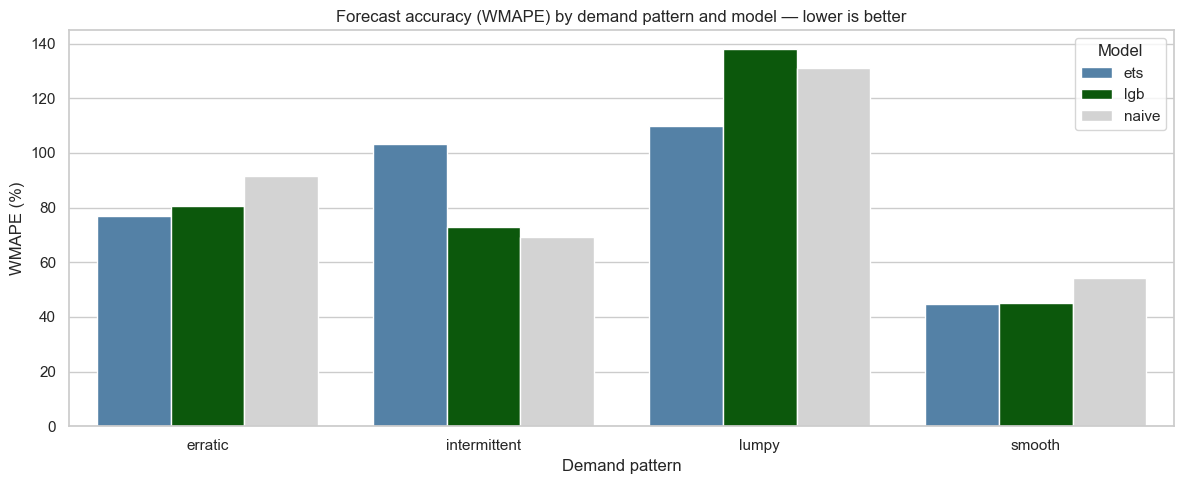

In [17]:
# Bar chart: WMAPE by model, faceted by demand pattern
fig, ax = plt.subplots(figsize=(12, 5))
chart_data = comparison[comparison["pattern"] != "ALL"].copy()
sns.barplot(data=chart_data, x="pattern", y="wmape", hue="model", ax=ax,
            palette={"naive": "lightgray", "ets": "steelblue", "lgb": "darkgreen"})
ax.set_title("Forecast accuracy (WMAPE) by demand pattern and model — lower is better")
ax.set_ylabel("WMAPE (%)")
ax.set_xlabel("Demand pattern")
plt.legend(title="Model")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_model_comparison_by_pattern.png", dpi=120, bbox_inches="tight")
plt.show()

In [18]:
# Save all forecasts to use in the inventory simulation
test_data.to_parquet(PROCESSED_DIR / "forecasts.parquet", index=False)
print(f"Saved forecasts: {test_data.shape}")
print(test_data.head())

Saved forecasts: (30296, 6)
                            id       date  actual  naive       ets       lgb
0  FOODS_1_001_CA_1_evaluation 2016-04-25       2      4  0.900188  1.873551
1  FOODS_1_001_CA_1_evaluation 2016-04-26       0      1  0.845417  0.918406
2  FOODS_1_001_CA_1_evaluation 2016-04-27       0      1  0.929851  1.099978
3  FOODS_1_001_CA_1_evaluation 2016-04-28       0      0  0.856778  0.776083
4  FOODS_1_001_CA_1_evaluation 2016-04-29       0      1  1.131657  1.529959


## Forecasting Results — Key Findings

**Models compared:**
1. Seasonal naive (one-week lag) — the baseline
2. Exponential smoothing (ETS) with weekly seasonality, fit per SKU
3. LightGBM global model with lag features, rolling means, calendar features, SNAP-CA, and price

**Headline results (WMAPE, all 30,296 test forecasts):**

| Pattern | Naive | ETS | LightGBM | Best |
|---|---|---|---|---|
| Smooth | 54.1% | 44.6% | 44.9% | ETS/LGB tie |
| Erratic | 91.7% | 76.9% | 80.4% | ETS |
| Intermittent | 69.1% | 103.3% | 72.8% | Naive |
| Lumpy | 131.1% | 110.0% | 137.9% | ETS |
| **Overall** | **73.3%** | **61.4%** | **63.6%** | **ETS** |

**Key takeaways — the most accurate model depends on the demand pattern:**

- **ETS wins overall** and on erratic SKUs (which dominate this slice at 68% of observations). Its per-SKU smoothing handles repeating weekly seasonality with high variance well.
- **Seasonal naive remains the best choice for intermittent SKUs.** When demand is sparse and noisy, sophisticated models overfit and the simplest method wins. This is a known result in the forecasting literature and shows up clearly in our data.
- **Lumpy SKUs defeat all three methods.** Even the best model has 110% WMAPE here. In production, lumpy SKUs should be flagged for separate treatment — probabilistic methods (Croston's SBA), pooled hierarchical models, or simply higher safety stock with regular human review.
- **Smooth SKUs are easiest** — both ETS and LightGBM achieve ~45% WMAPE, a respectable level for daily SKU-level retail forecasting.

**Bias observations:**
- All models are nearly bias-neutral on smooth and erratic SKUs (the patterns where we have most volume).
- ETS shows -2.93 bias on intermittent SKUs (chronic under-forecasting) — concerning for service-level planning.
- LightGBM has the cleanest bias profile on erratic SKUs (+0.05).

**What this means for the inventory simulation (Step 5):**
- We'll use ETS as the primary "best forecast" model in the simulation since it wins overall.
- We'll also include seasonal naive as the baseline policy to quantify the inventory cost difference.
- Because forecast error variance (not just the mean error) drives safety stock, even small WMAPE differences translate to measurable inventory differences — that's the story we're building toward.  
